In [3]:
import os
import scanpy as sc
import pandas as pd
EMBEDDING_DIR =  '/media/lleger/LaCie/mit/disease_vector/'
h5ad_files = [os.path.join(EMBEDDING_DIR, f) for f in os.listdir(EMBEDDING_DIR) if f.endswith(".h5ad")]

adata_list = [sc.read_h5ad(f) for f in sorted(h5ad_files)]
adata = adata_list[0].concatenate(adata_list[1:], index_unique=None)

adata.obs_names = [str(i) for i in range(adata.n_obs)]

sampled_indices = (
    adata.obs.groupby("disease", group_keys=False)
    .apply(lambda x: x.sample(min(50, len(x)), random_state=0))
    .index
)
adata = adata[sampled_indices, :]

adata.write_h5ad("../../../data/test_cxg_disease_balanced.h5ad")

KeyboardInterrupt: 

## Glioblastoma Drug Screen

In [4]:
EMBEDDING_DIR = '/media/lleger/LaCie/mit/disease_vector/vector_data/glioblastoma_study/'
RAW_DIR = "/media/lleger/LaCie/dump/disease-vector/glioblastoma/GSE148842_RAW"
import pandas as pd
metadata_matrix = pd.read_csv("GSE148842-GPL18573_series_matrix.txt", sep='\t', comment='!', header=None, index_col=0).T
metadata_matrix.columns = ['age', 'gender', 'tissue', 'disease', 'drug', 'protocol', 'filename']
metadata_matrix


,age,gender,tissue,disease,drug,protocol,filename
1,age: 52,gender: F,location: splenial extension into left parietal,"diagnosis: Glioblastoma, WHO Grade IV",treatment: vehicle (DMSO),Tumor specimens were collected immediately aft...,GSM4483741
2,age: 52,gender: F,location: splenial extension into left parietal,"diagnosis: Glioblastoma, WHO Grade IV",treatment: 2.5 uM etoposide,Tumor specimens were collected immediately aft...,GSM4483742
3,age: 65,gender: M,location: right parietal,"diagnosis: Glioblastoma, WHO Grade IV",treatment: vehicle (DMSO),Tumor specimens were collected immediately aft...,GSM4483743
4,age: 65,gender: M,location: right parietal,"diagnosis: Glioblastoma, WHO Grade IV",treatment: vehicle (DMSO),Tumor specimens were collected immediately aft...,GSM4483744
5,age: 65,gender: M,location: right parietal,"diagnosis: Glioblastoma, WHO Grade IV",treatment: 2.5 uM etoposide,Tumor specimens were collected immediately aft...,GSM4483745
6,age: 65,gender: M,location: right parietal,"diagnosis: Glioblastoma, WHO Grade IV",treatment: 0.2 uM panobinostat,Tumor specimens were collected immediately aft...,GSM4483746
7,age: 65,gender: M,location: right parietal,"diagnosis: Glioblastoma, WHO Grade IV",treatment: 50 nM RO4929097,Tumor specimens were collected immediately aft...,GSM4483747
8,age: 65,gender: M,location: right parietal,"diagnosis: Glioblastoma, WHO Grade IV",treatment: 50 uM Tazemetostat,Tumor specimens were collected immediately aft...,GSM4483748
9,age: 65,gender: M,location: right parietal,"diagnosis: Glioblastoma, WHO Grade IV",treatment: 1.8 nM Ispenisib,Tumor specimens were collected immediately aft...,GSM4483749
10,age: 65,gender: M,location: right parietal,"diagnosis: Glioblastoma, WHO Grade IV",treatment: 40 nM Ana-12,Tumor specimens were collected immediately aft...,GSM4483750


In [2]:
import sys
sys.path.append('../../../')
from polygene.model.model import load_trained_model
from polygene.data_utils.tokenization import normalise_str
EMBEDDING_DIR = '/media/lleger/LaCie/mit/disease_vector/vector_data/glioblastoma_study/'
data_path = "/media/lleger/LaCie/dump/disease-vector/glioblastoma/GSE148842_RAW/"

m, tok = load_trained_model("../../../runs/gesam_polygene_run_4/")
import json
import scanpy as sc
import os
import scipy.sparse as sp

from tqdm import tqdm
known_genes = set(list(json.load(open("../../data_utils/vocab/gene_ranking_map.json")).keys())) # checked overlap aftering dropping '.' in ENSEMBL ID

pbar = tqdm(os.listdir(data_path)[15:])
for file in pbar:
    drug = metadata_matrix[metadata_matrix['filename'] == file.split('_')[0]]['drug'].tolist()
    if not drug:
        print('ok')
        continue
    pbar.set_description(f'Formatting study to anndata: {drug}')
    df = pd.read_csv(data_path + file, sep="\t", index_col=0)
    df = df.drop(columns=df.columns[0])
    df.index = pd.Series(df.index.tolist()).apply(lambda x: x.split('.')[0]).tolist()
    
    adata = sc.AnnData(df.T)
    adata.obs['drug'] = drug * len(adata)
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    adata.X = sp.csr_matrix(adata.X)
    adata.write_h5ad(EMBEDDING_DIR + f"{file.split('.')[0]}.h5ad")

/home/lleger/miniconda3/envs/gene/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Formatting study to anndata: ['treatment: vehicle (DMSO)']:  11%|█         | 3/28 [00:11<01:39,  3.97s/it]     

ok
ok
ok
ok


Formatting study to anndata: ['treatment: 0.2 uM panobinostat']: 100%|██████████| 28/28 [02:22<00:00,  5.09s/it]

ok
ok
ok
ok
ok
ok
ok
ok
ok
ok


In [5]:
# Load glioblastoma from CxG
import sys
sys.path.append('../../../')
import numpy as np
import sys
import pandas as pd
sys.path.append('../../../')
from polygene.model.model import load_trained_model
from polygene.data_utils.tokenization import normalise_str
EMBEDDING_DIR = '/media/lleger/LaCie/mit/disease_vector/vector_data/glioblastoma_study/'
data_path = "/media/lleger/LaCie/dump/disease-vector/glioblastoma/GSE148842_RAW/"
m, tok = load_trained_model("../../../runs/gesam_polygene_run_4/")

cxg_embeddings = pd.read_pickle(EMBEDDING_DIR + "../glioblastoma_embeddings.pkl")

normal_embeddings = cxg_embeddings[0][cxg_embeddings[2][:, tok.phenotypic_types.index('disease')] == "[normal]"]
disease_embeddings = cxg_embeddings[0][cxg_embeddings[2][:, tok.phenotypic_types.index('disease')] != "[normal]"]
a, b = np.mean(normal_embeddings, axis=0), np.mean(disease_embeddings, axis=0)

/home/lleger/miniconda3/envs/gene/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [40]:
pd.Series(cxg_embeddings[2][:, tok.phenotypic_types.index('disease')]).value_counts(), disease_embeddings.shape

([glioblastoma]    9432
 [normal]          5117
 dtype: int64,
 (9432, 256))

In [ ]:
from polygene.eval.metrics import prepare_cell
import torch
from tqdm import tqdm
import os
import scanpy as sc
embeddings, labels, predictions, drug = ([] for _ in range(4))
for path in os.listdir(EMBEDDING_DIR):
    if path.endswith('pkl'): continue
    ad = sc.read_h5ad(EMBEDDING_DIR + path)#[:1000]
    for cell in tqdm(ad):
        cell_dict = prepare_cell(cell, tok)
        cell_dict['input_ids'][np.arange(1, 1 + len(tok.phenotypic_types))] = 2
        with torch.no_grad():
            output = m(**{key: val.to(m.device).unsqueeze(0) for key, val in cell_dict.items() if key != 'str_labels'})
        encoder_output = output.hidden_states
        embeddings.append(encoder_output[0, 1 + tok.phenotypic_types.index('disease')].detach().cpu().numpy())
        labels.append(cell_dict['str_labels'][1:1 + len(tok.phenotypic_types)])
        predictions.append([tok.flattened_tokens[output.logits.argmax(dim=-1).squeeze()[1 + idx]] 
                    for idx in range(len(tok.phenotypic_types))])
    drug.extend( metadata_matrix[metadata_matrix['filename'] == path.split('_')[0]]['drug'].tolist() * len(ad))
    
df_g = pd.DataFrame({"embeddings": embeddings, "labels": labels, "predictions": predictions, "drug": drug})
df_g.to_pickle(EMBEDDING_DIR + "embeddings.pkl")

In [63]:
# Analysis of df_g
import numpy as np
df_g = pd.read_pickle(EMBEDDING_DIR + "embeddings.pkl")
df_g['disease'] = np.array(df_g['predictions'].tolist())[:, tok.phenotypic_types.index('disease')]



v = b - a 
v /= np.dot(v,v)


s_a = np.array(df_g[(df_g['disease'] == "[normal]") & (df_g['drug'] == "treatment: none")]['embeddings'].tolist()).mean(axis=0)

#df_g = df_g[df_g['disease'] == '[glioblastoma]']

study_ranking = drug_effectiveness_rank = {
    "treatment: 0.2 uM panobinostat": 1,
    "treatment: 2.5 uM etoposide": 2,
    "treatment: 1.8 nM Ispenisib": 3,
    "treatment: 50 uM Tazemetostat": 4,
    "treatment: 50 nM RO4929097": 5,
    "treatment: 40 nM Ana-12": 6,
    "treatment: vehicle (DMSO)": 7,
    "treatment: none": 8
}
display(df_g.value_counts(['disease', 'drug']).reset_index())
centroid_study = df_g.groupby('drug').apply(lambda g: pd.Series({'centroid': np.array(g['embeddings']).mean(axis=0)})).reset_index()
centroid_study['Disease Vector Position'] = centroid_study['centroid'].apply(lambda c: (c - a) @ v)
centroid_study['Cosine Similarity of centroid vectors'] = centroid_study['centroid'].apply(lambda s: (np.dot(s-s_a, b-a))/(np.linalg.norm(b-a) * np.linalg.norm(s-s_a)))
centroid_study['Study Ranking'] = centroid_study['drug'].apply(lambda x: study_ranking.get(x,x))

#centroid_study[['drug' ,'Disease Vector Position', 'Cosine Similarity of centroid vectors', 'Study Ranking']].sort_values('Disease Vector Position')
centroid_study['drug'] = centroid_study['drug'].apply(lambda y: y.title())
centroid_study['Disease Vector Position'] = centroid_study['Disease Vector Position'].apply(lambda y: round(y,3))
centroid_study['Disease Vector Position'] = centroid_study['Disease Vector Position'].apply(lambda y: round(y,3))
centroid_study[['drug' ,'Disease Vector Position', 'Cosine Similarity of centroid vectors', 'Study Ranking']].sort_values('Cosine Similarity of centroid vectors')

,disease,drug,0
0,[glioblastoma],treatment: vehicle (DMSO),37245
1,[normal],treatment: vehicle (DMSO),20204
2,[glioblastoma],treatment: 2.5 uM etoposide,12655
3,[glioblastoma],treatment: 0.2 uM panobinostat,8049
4,[normal],treatment: 0.2 uM panobinostat,5415
...,...,...,...
65,[chronic_kidney_disease],treatment: 0.2 uM panobinostat,1
66,[chronic_kidney_disease],treatment: 40 nM Ana-12,1
67,[covid_19],treatment: vehicle (DMSO),1
68,[crohn_disease],treatment: 0.2 uM panobinostat,1


,drug,Disease Vector Position,Cosine Similarity of centroid vectors,Study Ranking
3,Treatment: 40 Nm Ana-12,0.594,0.195571,6
1,Treatment: 1.8 Nm Ispenisib,0.596,0.203693,3
5,Treatment: 50 Um Tazemetostat,0.598,0.208348,4
4,Treatment: 50 Nm Ro4929097,0.610,0.225019,5
0,Treatment: 0.2 Um Panobinostat,0.628,0.280673,1
7,Treatment: Vehicle (Dmso),0.640,0.348540,7
2,Treatment: 2.5 Um Etoposide,0.663,0.387766,2
6,Treatment: None,0.611,0.594990,8


In [25]:
display(df_g.value_counts(['disease', 'drug']).reset_index())
centroid_study = df_g.groupby('drug').apply(lambda g: pd.Series({'centroid': np.array(g['embeddings']).mean(axis=0)})).reset_index()
centroid_study['Disease Vector Position'] = centroid_study['centroid'].apply(lambda c: (c - s_a) @ v)
centroid_study['Cosine Similarity of Disease Vectors'] = centroid_study['centroid'].apply(lambda s: (np.dot(s-s_a, b-a))/(np.linalg.norm(b-a) * np.linalg.norm(s-s_a)))
centroid_study['Study Ranking'] = centroid_study['drug'].apply(lambda x: study_ranking.get(x,x))

#centroid_study[['drug' ,'Disease Vector Position', 'Cosine Similarity of centroid vectors', 'Study Ranking']].sort_values('Disease Vector Position')
centroid_study['drug'] = centroid_study['drug'].apply(lambda y: ' '.join(y.split(' ')[1:][::-1]).title())
centroid_study['Cosine Similarity of Disease Vectors'] = centroid_study['Cosine Similarity of Disease Vectors'].apply(lambda y: round(y,3))
result = centroid_study[['drug' ,"Cosine Similarity of Disease Vectors", 'Study Ranking']].sort_values('Cosine Similarity of Disease Vectors')
result.columns = ['Drug', 'Cosine Similarity of Disease Vectors', 'Study Ranking']
print(result.to_latex(index=None))

,disease,drug,0
0,[glioblastoma],treatment: vehicle (DMSO),37245
1,[glioblastoma],treatment: 2.5 uM etoposide,12655
2,[glioblastoma],treatment: 0.2 uM panobinostat,8049
3,[glioblastoma],treatment: none,5299
4,[glioblastoma],treatment: 40 nM Ana-12,2732
5,[glioblastoma],treatment: 50 nM RO4929097,2341
6,[glioblastoma],treatment: 50 uM Tazemetostat,1926
7,[glioblastoma],treatment: 1.8 nM Ispenisib,1174


\begin{tabular}{lrr}
\toprule
                Drug &  Cosine Similarity of Disease Vectors &  Study Ranking \\
\midrule
  Tazemetostat Um 50 &                                 0.391 &              4 \\
 Panobinostat Um 0.2 &                                 0.413 &              1 \\
     Ro4929097 Nm 50 &                                 0.415 &              5 \\
    Ispenisib Nm 1.8 &                                 0.419 &              3 \\
        Ana-12 Nm 40 &                                 0.454 &              6 \\
    Etoposide Um 2.5 &                                 0.463 &              2 \\
      (Dmso) Vehicle &                                 0.479 &              7 \\
                None &                                 0.600 &              8 \\
\bottomrule
\end{tabular}



/tmp/ipykernel_1056322/653127115.py:12: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(result.to_latex(index=None))


In [65]:
from sklearn.decomposition import PCA

proj = PCA(n_components=2, whiten=True, svd_solver="full")
df_cxg = pd.DataFrame({"embeddings": cxg_embeddings[0].tolist(), "disease": cxg_embeddings[2][:, 2]})
#df_cxg.sample()
#proj.fit(np.concatenate([np.array(df_g['embeddings'].tolist()), np.array(df_cxg['embeddings'].tolist())]))
proj.fit(np.concatenate([np.array(df_g['embeddings'].tolist())]))
#proj.fit(np.concatenate([np.array(df_cxg['embeddings'].tolist())]))
df_g[['x', 'y']] = proj.transform(np.array(df_g['embeddings'].tolist())).tolist()
df_cxg[['x', 'y']] = proj.transform(np.array(df_cxg['embeddings'].tolist())).tolist()
df_g = df_g[df_g['disease'].isin(['[glioblastoma]', '[normal]'])]

In [9]:
df_g.sample()

,embeddings,labels,predictions,drug,disease,x,y
85250,"[-1.3431323, -0.9068821, -1.2561659, 1.7141336...","[[mask], [mask], [mask], [mask], [mask]]","[[malignant_cell], [61_year_old_human_stage], ...",treatment: vehicle (DMSO),[glioblastoma],-0.471873,-0.709281


In [ ]:
df_cxg = pd.DataFrame({"embeddings": cxg_embeddings[0].tolist(), "disease": cxg_embeddings[2][:, 2]})
df_cxg[['x', 'y']] = proj.transform(np.array(df_cxg['embeddings'].tolist())).tolist()

df_cxg.sample()

,embeddings,disease,x,y
7175,"[0.24455134570598602, 0.9666798710823059, -0.2...",[glioblastoma],-3.411779,0.095902


71421
71421
71421
71421
71421
71421
71421
71421


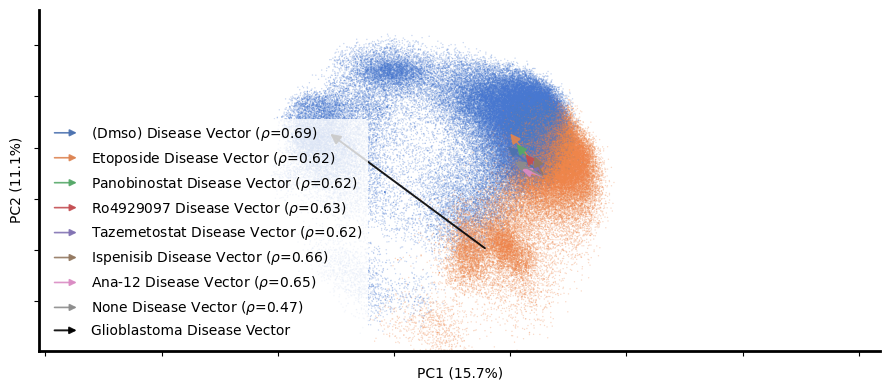

In [66]:
SAVE = False
fontsize = 12
surround_border = 5
surround_border_y = 1
import scanpy as sc, pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from matplotlib.patches import FancyArrowPatch
from matplotlib.legend_handler import HandlerPatch

explained_var = proj.explained_variance_ratio_
fig, ax = plt.subplots(1, 1, figsize=(9,4), dpi=100)

all_diseases = pd.concat([df_g['disease'], df_cxg['disease']]).unique().tolist()
palette = dict(zip(all_diseases, sns.color_palette('muted', n_colors=len(all_diseases))))

sns.scatterplot(data=df_g, x='x', y='y', hue=df_g['disease'],
                palette=palette, s=1, alpha=0.3, ax=ax, linewidth=0, zorder=1)
sns.scatterplot(data=df_cxg, x='x', y='y', hue=df_cxg['disease'],
                palette=palette, s=1, alpha=0.3, ax=ax, linewidth=0, zorder=1)

normal_emb_g = np.vstack(df_g[df_g['disease']=="[normal]"]['embeddings']).mean(0)
drug_vectors = {}
for drug in df_g['drug'].unique():
    print((df_g['disease']=='[glioblastoma]').sum())
    drug_emb = np.vstack(df_g[(df_g['drug']==drug) & (df_g['disease']=='[glioblastoma]')]['embeddings']).mean(0)
    drug_vectors[drug] = drug_emb - normal_emb_g

drug_colors = sns.color_palette('deep', n_colors=len(drug_vectors))
normal_umap_g = df_g[df_g['disease']=="[normal]"][['x','y']].mean().values

normal_emb_c = np.vstack(df_cxg[df_cxg['disease']=="[normal]"]['embeddings']).mean(0)
gbm_emb_c = np.vstack(df_cxg[df_cxg['disease']=="[glioblastoma]"]['embeddings']).mean(0)
gbm_vector = gbm_emb_c - normal_emb_c
cos = lambda a,b: np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b))

for (drug, v), c in zip(drug_vectors.items(), drug_colors):
    r = cos(v, gbm_vector)
    end = df_g[df_g['drug']==drug][['x','y']].mean().values
    ax.add_patch(FancyArrowPatch(tuple(normal_umap_g), tuple(end),
                                 arrowstyle='-|>', mutation_scale=15,
                                 color=c, linewidth=1.2, alpha=0.9, zorder=3,
                                 label=f"{drug.split(' ')[-1].title()} Disease Vector ($\\rho$={r:.2f})"))

normal_umap_c = df_cxg[df_cxg['disease']=="[normal]"][['x','y']].mean().values
gbm_umap_c = df_cxg[df_cxg['disease']=="[glioblastoma]"][['x','y']].mean().values

ax.add_patch(FancyArrowPatch(tuple(normal_umap_c), tuple(gbm_umap_c),
                             arrowstyle='-|>', mutation_scale=15,
                             color='black', linewidth=1.4, alpha=0.9,
                             zorder=3, label="Glioblastoma Disease Vector"))

def make_legend_quiver(legend, orig_handle, xdescent, ydescent, width, height, fontsize):
    return FancyArrowPatch((0, height*0.5), (width, height*0.5),
                           arrowstyle='-|>', mutation_scale=fontsize,
                           color=orig_handle.get_edgecolor() if hasattr(orig_handle,"get_edgecolor") else orig_handle.get_facecolor(),
                           linewidth=1)

ax.set_xticklabels([]); ax.set_yticklabels([])
ax.spines[['top','right']].set_linewidth(0)
ax.spines[['bottom','left']].set_linewidth(2)
ax.set_xlim(df_g['x'].quantile(.01)-surround_border, df_g['x'].quantile(.99)+surround_border)
ax.set_ylim(df_g['y'].quantile(.01)-surround_border_y, df_g['y'].quantile(.99)+surround_border_y)
ax.set_xlabel(f'PC1 ({explained_var[0]*100:.1f}%)', fontsize=fontsize-2)
ax.set_ylabel(f'PC2 ({explained_var[1]*100:.1f}%)', fontsize=fontsize-2)

handles, legend_labels_ = ax.get_legend_handles_labels()
legend_labels_ = [' '.join([w.capitalize() for w in x[1:-1].split('_')]).replace(' Right Ventricular','')
                  if '[' in x else x for x in legend_labels_]
handles, legend_labels_ = zip(*[(h, l) for h, l in zip(handles, legend_labels_) if "Vector" in l])

legend = ax.legend(handles, legend_labels_, frameon=True, edgecolor='none',
                   framealpha=0.8, fontsize=fontsize-2,
                   handler_map={FancyArrowPatch: HandlerPatch(patch_func=make_legend_quiver)})

for h in legend.legendHandles:
    if hasattr(h,"set_markersize"): h.set_markersize(6); h.set_alpha(1)

plt.tight_layout()
plt.show()


/tmp/ipykernel_1173718/2688161824.py:12: UserWarning: The palette list has more values (10) than needed (9), which may not be intended.
  sns.scatterplot(data=df_g, x='x', y='y', hue=df_g['disease_drug'],
/tmp/ipykernel_1173718/2688161824.py:15: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.scatterplot(data=df_cxg, x='x', y='y', hue=df_cxg['disease'],


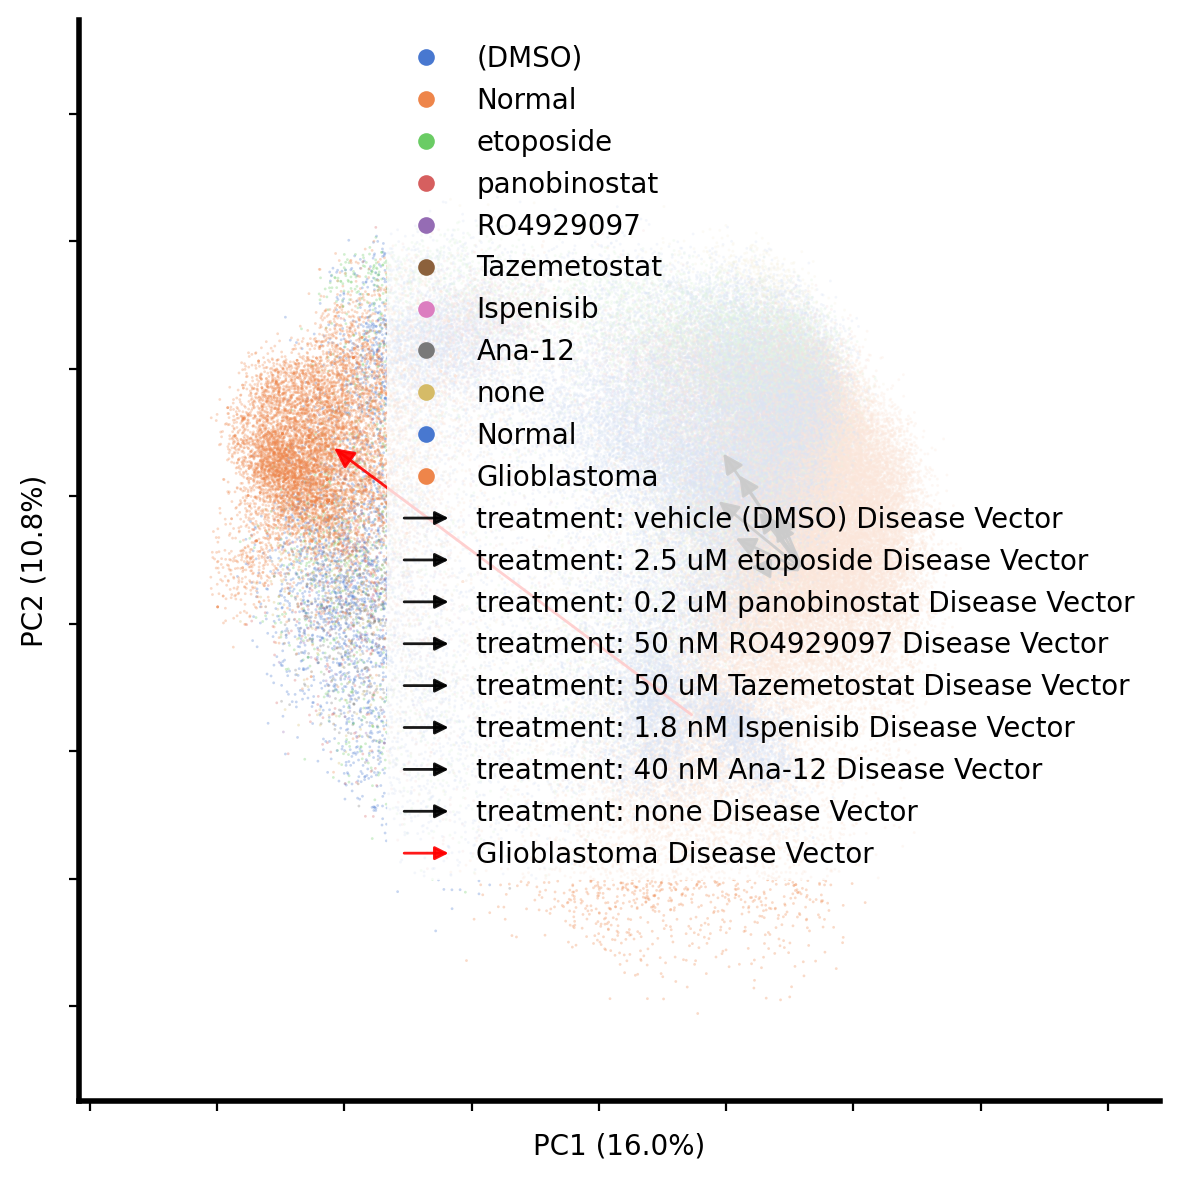

In [ ]:
SAVE = False
fontsize = 12
surround_border = 2
import scanpy as sc, pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from matplotlib.patches import FancyArrowPatch
from matplotlib.legend_handler import HandlerPatch

explained_var = proj.explained_variance_ratio_
fig, ax = plt.subplots(1, 1, figsize=(6,6), dpi=200)

df_g['disease_drug'] = df_g.apply(lambda g: g['drug'].split(' ')[-1] if g['disease']=="[glioblastoma]" else g['disease'][1:-1].title(), axis=1)
sns.scatterplot(data=df_g, x='x', y='y', hue=df_g['disease_drug'],
                palette=sns.color_palette('muted', n_colors=10), s=1,
                alpha=0.3, ax=ax, linewidth=0, zorder=1)
sns.scatterplot(data=df_cxg, x='x', y='y', hue=df_cxg['disease'],
                palette=sns.color_palette('muted', n_colors=10), s=1,
                alpha=0.3, ax=ax, linewidth=0, zorder=1)

normal_emb_g = np.vstack(df_g[df_g['disease']=="[normal]"]['embeddings']).mean(0)
drug_vectors = {}
for drug in df_g['drug'].unique():
    drug_emb = np.vstack(df_g[df_g['drug']==drug]['embeddings']).mean(0)
    drug_vectors[drug] = drug_emb - normal_emb_g

normal_umap_g = df_g[df_g['disease']=="[normal]"][['x','y']].mean().values
for drug, v in drug_vectors.items():
    end = df_g[df_g['drug']==drug][['x','y']].mean().values
    ax.add_patch(FancyArrowPatch(tuple(normal_umap_g), tuple(end),
                                 arrowstyle='-|>', mutation_scale=15,
                                 color='black', linewidth=1, alpha=0.9,
                                 zorder=3, label=f"{drug.split(' ')[-1].title()} Disease Vector"))

normal_emb_c = np.vstack(df_cxg[df_cxg['disease']=="[normal]"]['embeddings']).mean(0)
gbm_emb_c = np.vstack(df_cxg[df_cxg['disease']=="[glioblastoma]"]['embeddings']).mean(0)
normal_umap_c = df_cxg[df_cxg['disease']=="[normal]"][['x','y']].mean().values
gbm_umap_c = df_cxg[df_cxg['disease']=="[glioblastoma]"][['x','y']].mean().values
ax.add_patch(FancyArrowPatch(tuple(normal_umap_c), tuple(gbm_umap_c),
                             arrowstyle='-|>', mutation_scale=15,
                             color='red', linewidth=1, alpha=0.9,
                             zorder=3, label="Glioblastoma Disease Vector"))

def make_legend_quiver(legend, orig_handle, xdescent, ydescent, width, height, fontsize):
    return FancyArrowPatch((0, height*0.5), (width, height*0.5), arrowstyle='-|>', mutation_scale=fontsize, color='black', linewidth=1)

ax.set_xticklabels([]); ax.set_yticklabels([])
ax.spines[['top','right']].set_linewidth(0)
ax.spines[['bottom','left']].set_linewidth(2)
ax.set_xlim(df_g['x'].quantile(.01)-surround_border, df_g['x'].quantile(.99)+surround_border)
ax.set_ylim(df_g['y'].quantile(.01)-surround_border, df_g['y'].quantile(.99)+surround_border)
ax.set_xlabel(f'PC1 ({explained_var[0]*100:.1f}%)', fontsize=fontsize-2)
ax.set_ylabel(f'PC2 ({explained_var[1]*100:.1f}%)', fontsize=fontsize-2)

handles, legend_labels_ = ax.get_legend_handles_labels()
legend_labels_ = [' '.join([w.capitalize() for w in x[1:-1].split('_')]).replace(' Right Ventricular','') if '[' in x else x for x in legend_labels_]
legend = ax.legend(handles, legend_labels_, frameon=True, edgecolor='none', framealpha=0.8, fontsize=fontsize-2, handler_map={FancyArrowPatch: HandlerPatch(patch_func=make_legend_quiver)})
for h in legend.legendHandles:
    if hasattr(h,"set_markersize"): h.set_markersize(6); h.set_alpha(1)

plt.tight_layout()
plt.show()


/tmp/ipykernel_1173718/1519503980.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_g['disease_drug'] = df_g.apply(lambda g: g['drug'].split(' ')[-1] if g['disease'] == "[glioblastoma]" else g['disease'][1:-1].title(), axis=1)
/tmp/ipykernel_1173718/1519503980.py:9: UserWarning: The palette list has more values (10) than needed (9), which may not be intended.
  sns.scatterplot(data=df_g, x='x', y='y', hue=df_g['disease_drug'],
/tmp/ipykernel_1173718/1519503980.py:12: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.scatterplot(data=df_cxg, x='x', y='y', hue=df_cxg['disease'],


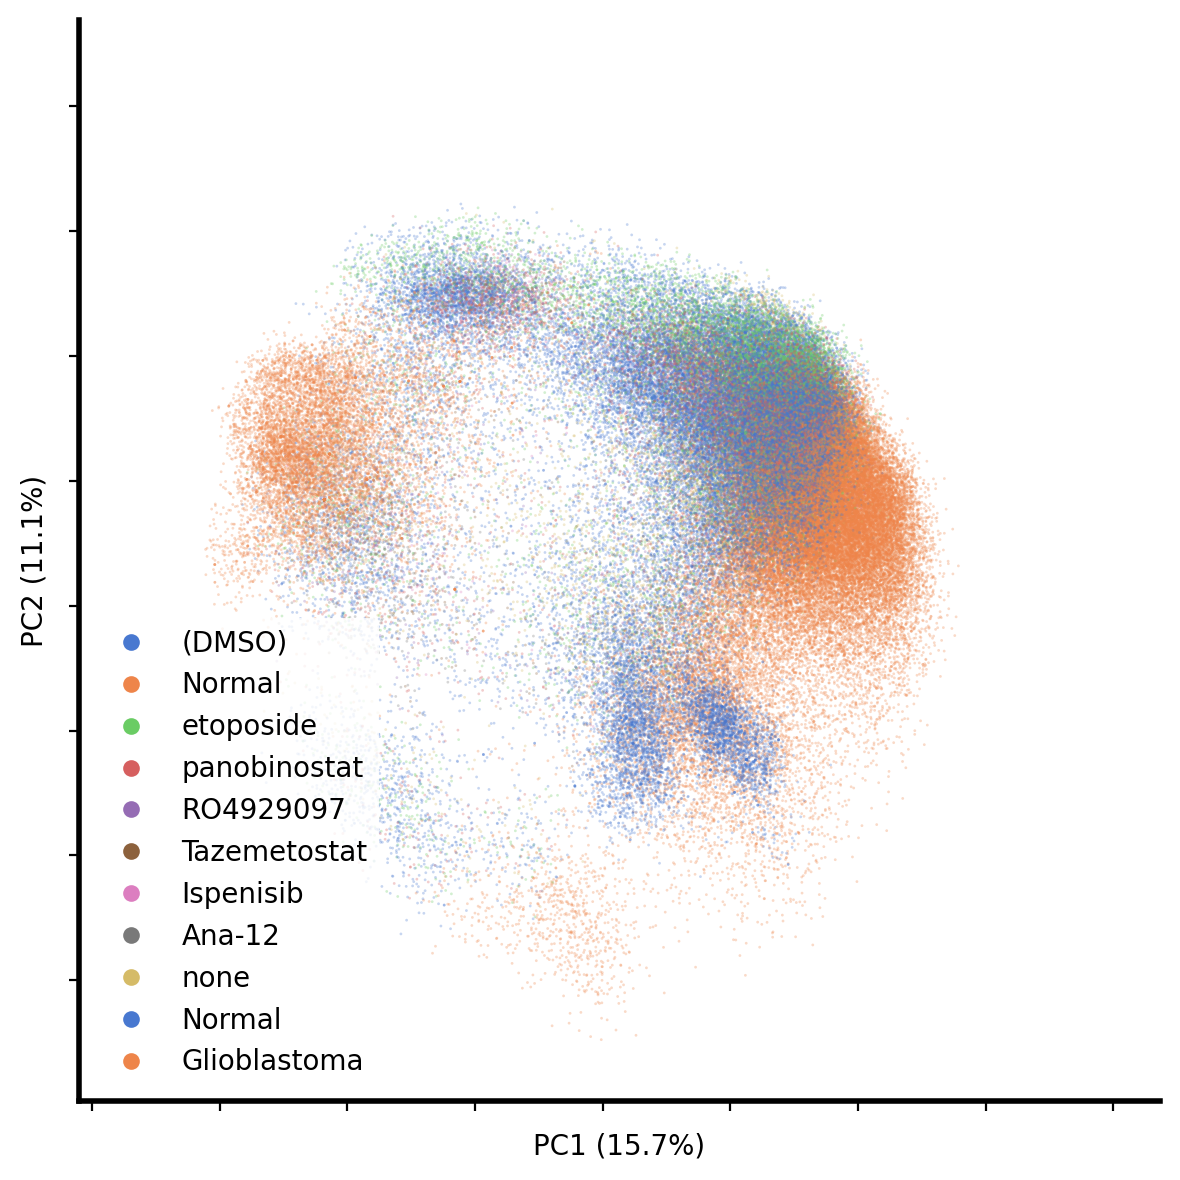

In [ ]:
SAVE = False
fontsize = 12
surround_border = 2
import scanpy as sc, pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
explained_var = proj.explained_variance_ratio_
fig, ax = plt.subplots(1, 1, figsize=(6,6), dpi=200)

df_g['disease_drug'] = df_g.apply(lambda g: g['drug'].split(' ')[-1] if g['disease'] == "[glioblastoma]" else g['disease'][1:-1].title(), axis=1)
sns.scatterplot(data=df_g, x='x', y='y', hue=df_g['disease_drug'],
                palette=sns.color_palette('muted', n_colors=10), s=1,
                alpha=0.3, ax=ax, linewidth=0, zorder=1)

sns.scatterplot(data=df_cxg, x='x', y='y', hue=df_cxg['disease'],
                palette=sns.color_palette('muted', n_colors=10), s=1,
                alpha=0.3, ax=ax, linewidth=0, zorder=1)


ax.set_xticklabels([]); ax.set_yticklabels([])
ax.spines[['top','right']].set_linewidth(0)
ax.spines[['bottom','left']].set_linewidth(2)
ax.set_xlim(df_g['x'].quantile(.01)-surround_border, df_g['x'].quantile(.99)+surround_border)
ax.set_ylim(df_g['y'].quantile(.01)-surround_border, df_g['y'].quantile(.99)+surround_border)
ax.set_xlabel(f'PC1 ({explained_var[0]*100:.1f}%)', fontsize=fontsize-2)
ax.set_ylabel(f'PC2 ({explained_var[1]*100:.1f}%)', fontsize=fontsize-2)

handles, legend_labels_ = ax.get_legend_handles_labels()
legend_labels_ = [' '.join([word.capitalize() for word in x[1:-1].split('_')]).replace(' Right Ventricular', '')
                if '[' in x else x for x in legend_labels_]
#legend_labels_ = [x.replace(' ', '\n') if len(x) > 17 and "\n" not in x else x for x in legend_labels_]
legend = ax.legend(handles, legend_labels_, frameon=True, edgecolor='none', framealpha=0.8,
                fontsize=fontsize-2,)# handler_map={FancyArrowPatch: HandlerPatch(patch_func=make_legend_quiver)})
for handle in legend.legendHandles:
    if hasattr(handle, "set_markersize"): 
        handle.set_markersize(6)
        handle.set_alpha(1)

plt.tight_layout()

#if SAVE: plt.savefig(f"../figures/winding/{file_path.split('.')[0]}_{metric_name}.png", dpi=600)
plt.show()
#break

In [ ]:
centroid_study[['drug' ,'Disease Vector Position', 'Cosine Similarity of centroid vectors', 'Study Ranking']].sort_values('Disease Vector Position')
# features related to the change of state. 

,drug,Disease Vector Position,Cosine Similarity of centroid vectors,Study Ranking
5,treatment: 50 uM Tazemetostat,0.685100,0.391291,4
6,treatment: none,0.690890,0.600090,8
0,treatment: 0.2 uM panobinostat,0.695570,0.413382,1
1,treatment: 1.8 nM Ispenisib,0.697789,0.419223,3
7,treatment: vehicle (DMSO),0.708690,0.478995,7
4,treatment: 50 nM RO4929097,0.709641,0.415369,5
2,treatment: 2.5 uM etoposide,0.711461,0.462677,2
3,treatment: 40 nM Ana-12,0.720375,0.453856,6


In [8]:
df_g = pd.DataFrame({"embeddings": embeddings, "labels": labels, "predictions": predictions, "drug": drug})
df_g.to_pickle(EMBEDDING_DIR + "embeddings.pkl")

In [ ]:

df_g['disease'] = np.array(df_g['predictions'].tolist())[:, tok.phenotypic_types.index('disease')]

NameError: name 'df' is not defined